# Exploratory Data Analysis (EDA)

## Objective

The goal of this analysis is to explore the ICBC crash dataset (https://www.kaggle.com/datasets/tcashion/icbc-vehicle-crash-dataset/data), understand its structure and quality, identify patterns related to casualty crashes, and determine whether the available variables are suitable for predicting high-risk intersections.

This EDA will:
- Examine data quality and completeness
- Understand the distribution of casualty crashes
- Explore temporal and geographic patterns
- Investigate relationships between crash characteristics and crash severity
- Generate observations that guide feature engineering and model selection

In [11]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [12]:
with open("British_Columbia_Full_Data_data.csv", "rb") as f:
    print(f.read(16))

# load dataset
df = pd.read_csv(
    "British_Columbia_Full_Data_data.csv", encoding="utf-16", sep="\t", low_memory=False
)

# dataset shape and head
print(df.shape)
df.head()

b'\xff\xfeC\x00r\x00a\x00s\x00h\x00 \x00B\x00'
(1380474, 29)


,Crash Breakdown 2,Date Of Loss Year,Animal Involved,Crash Severity,Cyclist Involved,Day Of Week,Derived Crash Congifuration,Heavy Veh Involved,Intersection Crash,Month Of Year,Motorcycle Involved,Municipality Name (ifnull),Parked Vehicle Involved,Parking Lot Crash,Pedestrian Involved,Region,Street Full Name (ifnull),Time Category,Municipality Name,Road Location Description,Street Full Name,Metric Selector,Total Crashes,Total Victims,Cross Street Full Name,Latitude,Longitude,Mid Block Crash,Municipality With Boundary
0,SURREY,2018,No,CASUALTY CRASH,No,FRIDAY,REAR END,No,No,SEPTEMBER,No,SURREY,No,No,No,LOWER MAINLAND,PORT MANN BRIDGE,06:00-08:59,SURREY,PORT MANN BRIDGE,PORT MANN BRIDGE,1,1,1,NaN,49.225890,-122.817994,N,COQUITLAM & SURREY
1,SURREY,2018,No,CASUALTY CRASH,No,FRIDAY,REAR END,No,No,JUNE,No,SURREY,No,No,No,LOWER MAINLAND,PORT MANN BRIDGE,09:00-11:59,SURREY,PORT MANN BRIDGE,PORT MANN BRIDGE,1,1,1,NaN,49.225890,-122.817994,N,COQUITLAM & SURREY
2,SURREY,2018,No,CASUALTY CRASH,No,FRIDAY,CONFLICTED,No,No,APRIL,No,SURREY,No,No,No,LOWER MAINLAND,PORT MANN BRIDGE,12:00-14:59,SURREY,PORT MANN BRIDGE,PORT MANN BRIDGE,1,1,1,NaN,49.225890,-122.817994,N,COQUITLAM & SURREY
3,COQUITLAM,2018,No,CASUALTY CRASH,No,FRIDAY,REAR END,No,No,JANUARY,No,COQUITLAM,No,No,No,LOWER MAINLAND,GLEN DR,12:00-14:59,COQUITLAM,GLEN DR,GLEN DR,1,1,1,NaN,49.282743,-122.806313,N,COQUITLAM
4,SURREY,2018,No,CASUALTY CRASH,No,FRIDAY,REAR END,No,No,JUNE,No,SURREY,No,No,No,LOWER MAINLAND,PORT MANN BRIDGE,12:00-14:59,SURREY,PORT MANN BRIDGE,PORT MANN BRIDGE,1,1,2,NaN,49.225890,-122.817994,N,COQUITLAM & SURREY


In [13]:
# dataset info
print(df.shape)
df.info()

(1380474, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380474 entries, 0 to 1380473
Data columns (total 29 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Crash Breakdown 2            1380474 non-null  object 
 1   Date Of Loss Year            1380474 non-null  int64  
 2   Animal Involved              1380474 non-null  object 
 3   Crash Severity               1380474 non-null  object 
 4   Cyclist Involved             1380474 non-null  object 
 5   Day Of Week                  1380474 non-null  object 
 6   Derived Crash Congifuration  1380474 non-null  object 
 7   Heavy Veh Involved           1380474 non-null  object 
 8   Intersection Crash           1380474 non-null  object 
 9   Month Of Year                1380474 non-null  object 
 10  Motorcycle Involved          1380474 non-null  object 
 11  Municipality Name (ifnull)   1380474 non-null  object 
 12  Parked Vehicle Involved     

In [14]:
# dataset columns
df.columns.tolist()

['Crash Breakdown 2',
 'Date Of Loss Year',
 'Animal Involved',
 'Crash Severity',
 'Cyclist Involved',
 'Day Of Week',
 'Derived Crash Congifuration',
 'Heavy Veh Involved',
 'Intersection Crash',
 'Month Of Year',
 'Motorcycle Involved',
 'Municipality Name (ifnull)',
 'Parked Vehicle Involved',
 'Parking Lot Crash',
 'Pedestrian Involved',
 'Region',
 'Street Full Name (ifnull)',
 'Time Category',
 'Municipality Name',
 'Road Location Description',
 'Street Full Name',
 'Metric Selector',
 'Total Crashes',
 'Total Victims',
 'Cross Street Full Name',
 'Latitude',
 'Longitude',
 'Mid Block Crash',
 'Municipality With Boundary']

In [15]:
# missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing

Cross Street Full Name        740461
Municipality With Boundary    293137
Longitude                     293137
Latitude                      293137
Municipality Name              20722
Street Full Name                2827
Street Full Name (ifnull)        191
Road Location Description        178
dtype: int64

In [16]:
# dataset missing values percentage
(df.isnull().mean().mul(100).sort_values(ascending=False).round(2))

Cross Street Full Name         53.64
Municipality With Boundary     21.23
Longitude                      21.23
Latitude                       21.23
Municipality Name               1.50
Street Full Name                0.20
Street Full Name (ifnull)       0.01
Road Location Description       0.01
Region                          0.00
Mid Block Crash                 0.00
Total Victims                   0.00
Total Crashes                   0.00
Metric Selector                 0.00
Time Category                   0.00
Crash Breakdown 2               0.00
Date Of Loss Year               0.00
Parking Lot Crash               0.00
Parked Vehicle Involved         0.00
Municipality Name (ifnull)      0.00
Motorcycle Involved             0.00
Month Of Year                   0.00
Intersection Crash              0.00
Heavy Veh Involved              0.00
Derived Crash Congifuration     0.00
Day Of Week                     0.00
Cyclist Involved                0.00
Crash Severity                  0.00
A

In [17]:
# duplicate rows
print(df.duplicated().sum())

0


### Vancouver specific DF

In [18]:
vancouver_df = df[df["Municipality Name (ifnull)"] == "VANCOUVER"].copy()

print(vancouver_df.shape)

(225148, 29)


In [19]:
# vancouver dataset missing values percentage
(vancouver_df.isnull().mean().mul(100).sort_values(ascending=False).round(2))

Cross Street Full Name         38.33
Municipality With Boundary     10.20
Longitude                      10.20
Latitude                       10.20
Street Full Name                0.16
Street Full Name (ifnull)       0.01
Road Location Description       0.00
Region                          0.00
Mid Block Crash                 0.00
Total Victims                   0.00
Total Crashes                   0.00
Metric Selector                 0.00
Municipality Name               0.00
Time Category                   0.00
Crash Breakdown 2               0.00
Date Of Loss Year               0.00
Parking Lot Crash               0.00
Parked Vehicle Involved         0.00
Municipality Name (ifnull)      0.00
Motorcycle Involved             0.00
Month Of Year                   0.00
Intersection Crash              0.00
Heavy Veh Involved              0.00
Derived Crash Congifuration     0.00
Day Of Week                     0.00
Cyclist Involved                0.00
Crash Severity                  0.00
A

### Crash Severity

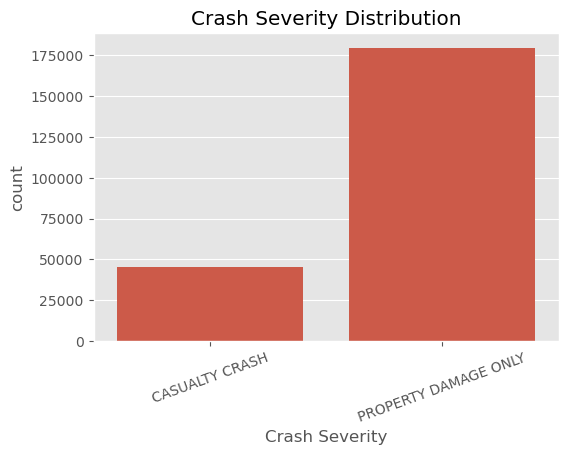

In [20]:
# target variable distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=vancouver_df, x="Crash Severity")

plt.title("Crash Severity Distribution")
plt.xticks(rotation=20)

plt.show()

In [21]:
# Target variable percentages
(vancouver_df["Crash Severity"].value_counts(normalize=True).mul(100).round(2))

Crash Severity
PROPERTY DAMAGE ONLY    79.8
CASUALTY CRASH          20.2
Name: proportion, dtype: float64

### Temporal exploration

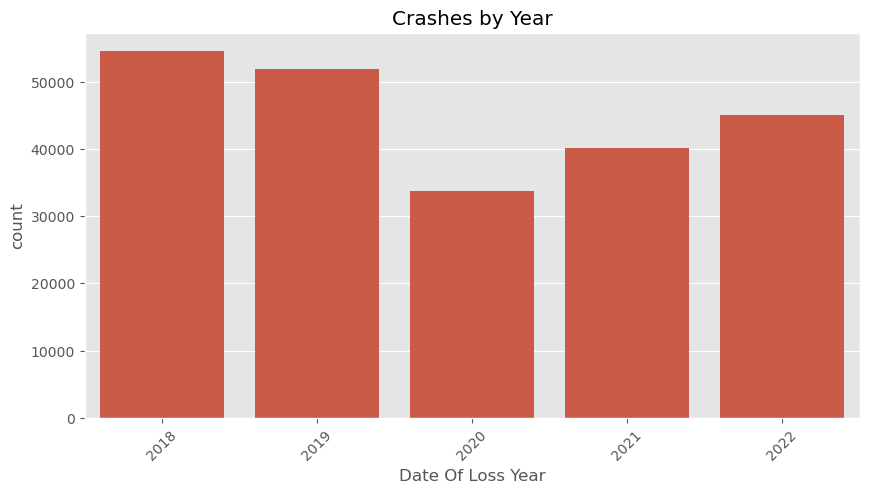

In [22]:
# crashes by year
plt.figure(figsize=(10, 5))

sns.countplot(data=vancouver_df, x="Date Of Loss Year")

plt.xticks(rotation=45)

plt.title("Crashes by Year")
plt.show()

Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Date Of Loss Year,,
2018,0.214134,0.785866
2019,0.211301,0.788699
2020,0.203017,0.796983
2021,0.199631,0.800369
2022,0.178117,0.821883


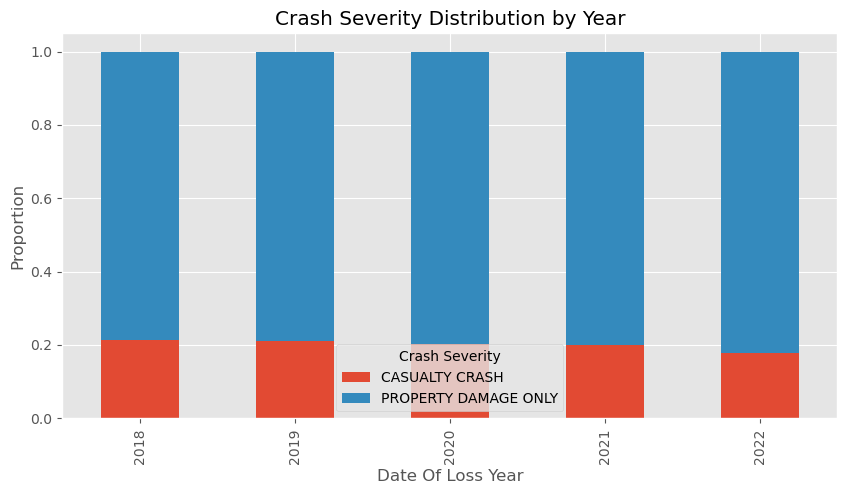

In [23]:
year_severity = pd.crosstab(
    vancouver_df["Date Of Loss Year"], vancouver_df["Crash Severity"], normalize="index"
)

display(year_severity)

year_severity.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.ylabel("Proportion")
plt.title("Crash Severity Distribution by Year")
plt.show()

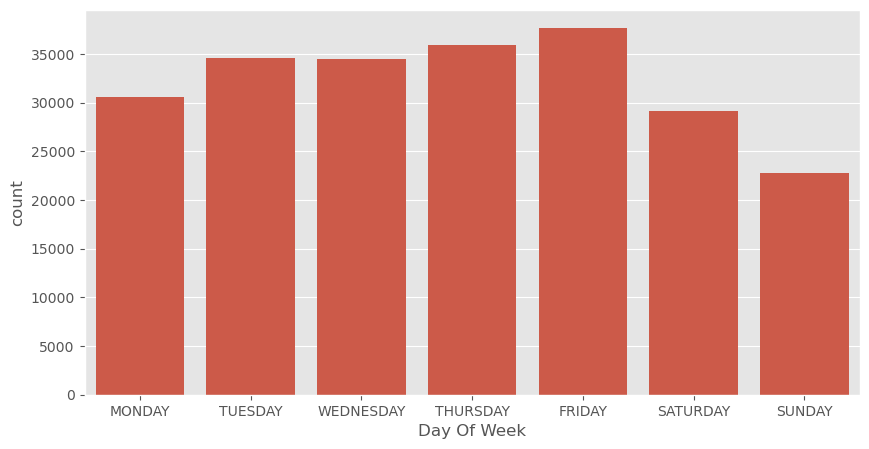

In [24]:
# crashes by day of the week

order = ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY"]

plt.figure(figsize=(10, 5))

sns.countplot(data=vancouver_df, x="Day Of Week", order=order)

plt.show()

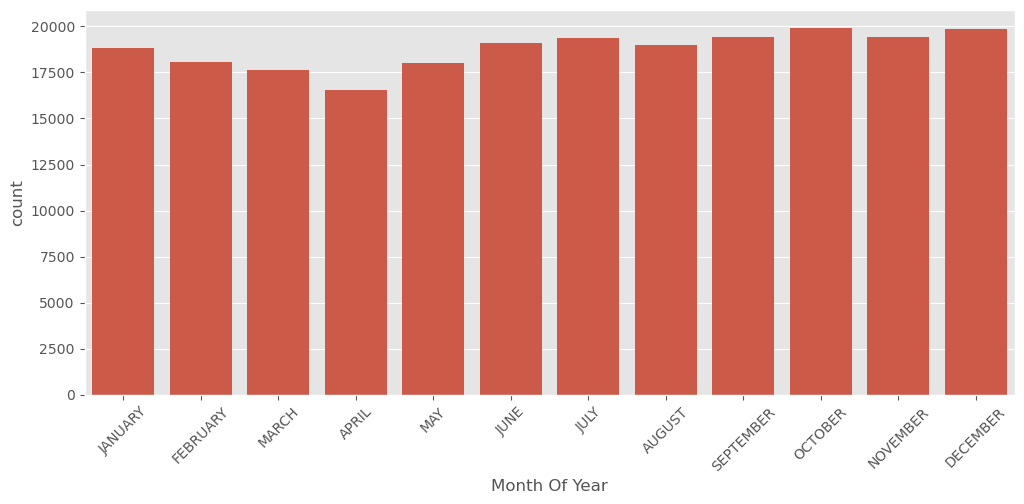

In [25]:
# crashes by month

month_order = [
    "JANUARY",
    "FEBRUARY",
    "MARCH",
    "APRIL",
    "MAY",
    "JUNE",
    "JULY",
    "AUGUST",
    "SEPTEMBER",
    "OCTOBER",
    "NOVEMBER",
    "DECEMBER",
]

plt.figure(figsize=(12, 5))

sns.countplot(data=vancouver_df, x="Month Of Year", order=month_order)

plt.xticks(rotation=45)

plt.show()

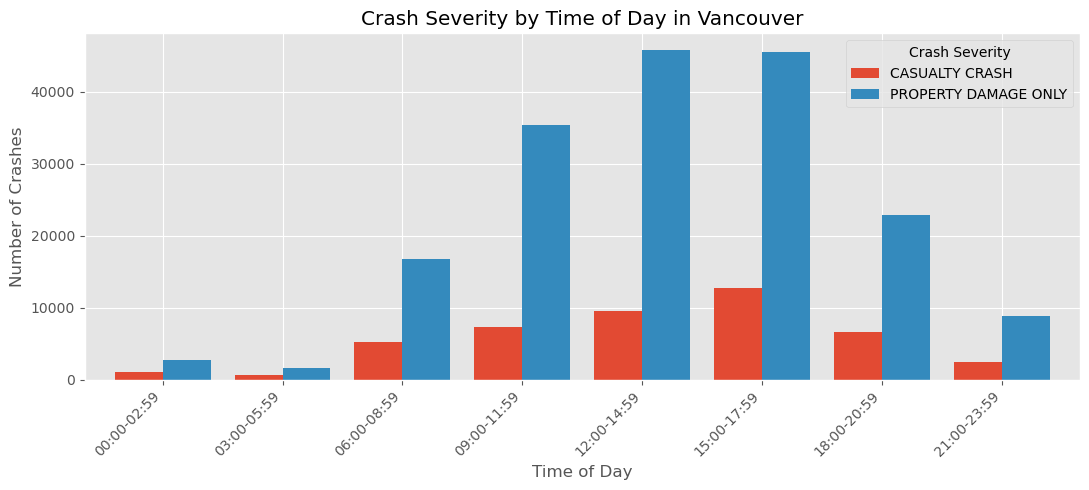

In [26]:
time_rates = pd.crosstab(
    vancouver_df["Time Category"], vancouver_df["Crash Severity"]
)

time_order = [
    "00:00-02:59",
    "03:00-05:59",
    "06:00-08:59",
    "09:00-11:59",
    "12:00-14:59",
    "15:00-17:59",
    "18:00-20:59",
    "21:00-23:59",
]

time_rates = time_rates.reindex(time_order)[["CASUALTY CRASH", "PROPERTY DAMAGE ONLY"]]

ax = time_rates.plot(kind="bar", stacked=False, figsize=(11, 5), width=0.8)

ax.set_title("Crash Severity by Time of Day in Vancouver")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Number of Crashes")
ax.legend(title="Crash Severity")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

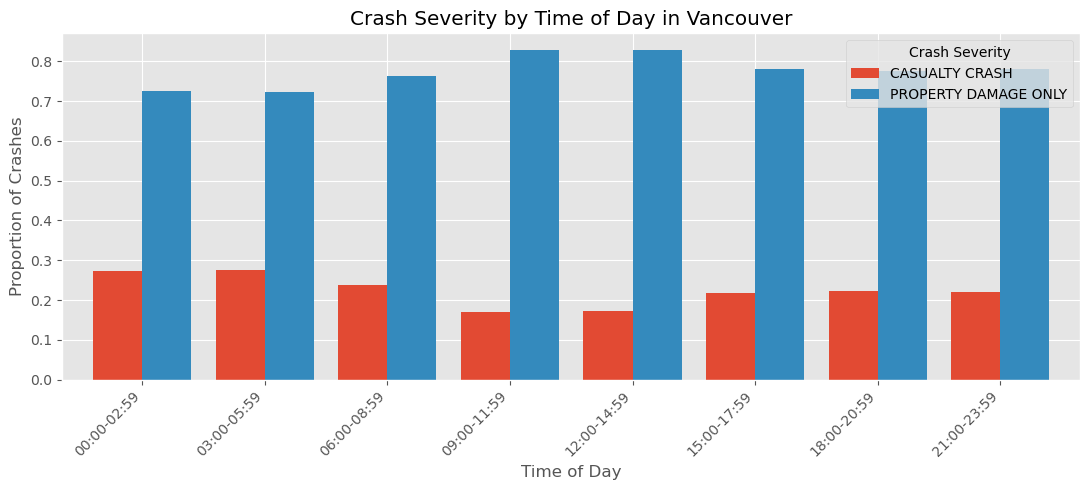

In [27]:
time_rates = pd.crosstab(vancouver_df["Time Category"], vancouver_df["Crash Severity"], normalize="index")

time_order = [
    "00:00-02:59",
    "03:00-05:59",
    "06:00-08:59",
    "09:00-11:59",
    "12:00-14:59",
    "15:00-17:59",
    "18:00-20:59",
    "21:00-23:59",
]

time_rates = time_rates.reindex(time_order)[["CASUALTY CRASH", "PROPERTY DAMAGE ONLY"]]

ax = time_rates.plot(kind="bar", stacked=False, figsize=(11, 5), width=0.8)

ax.set_title("Crash Severity by Time of Day in Vancouver")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Proportion of Crashes")
ax.legend(title="Crash Severity")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### BC Geographic analysis

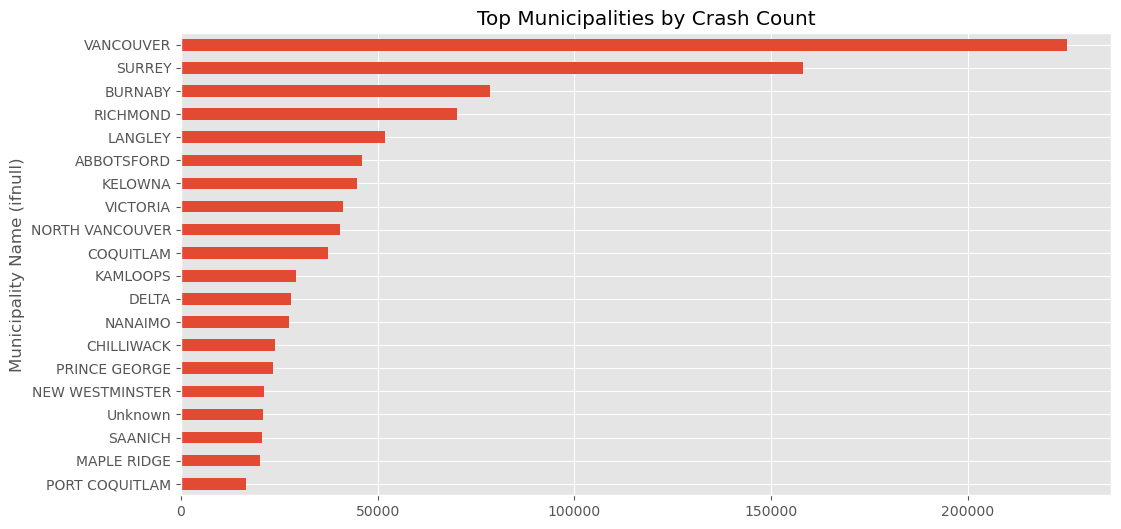

In [28]:
# crashes by municipality
plt.figure(figsize=(12, 6))

(df["Municipality Name (ifnull)"].value_counts().head(20).sort_values().plot.barh())

plt.title("Top Municipalities by Crash Count")
plt.show()

### Vancouver Crash characteristics

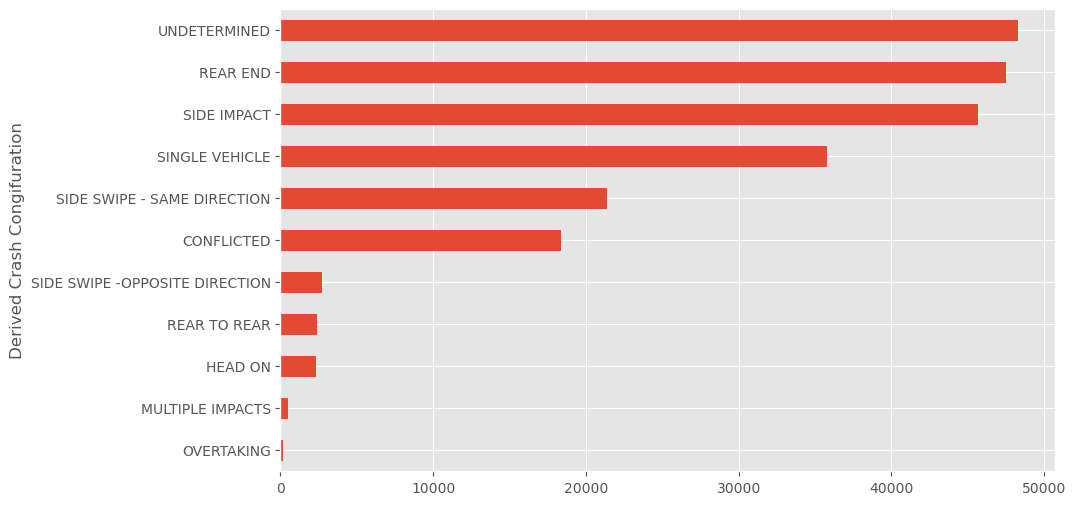

In [29]:
# crashes by derived crash configuration
plt.figure(figsize=(10, 6))

(vancouver_df["Derived Crash Congifuration"].value_counts().head(15).sort_values().plot.barh())

plt.show()

### Vancouver Binary crash variables

In [30]:
binary_cols = [
    "Animal Involved",
    "Cyclist Involved",
    "Heavy Veh Involved",
    "Motorcycle Involved",
    "Pedestrian Involved",
    "Intersection Crash",
    "Parking Lot Crash",
    "Mid Block Crash",
    "Parked Vehicle Involved",
]

for col in binary_cols:
    print(f"\n{col}")
    print(vancouver_df[col].value_counts())


Animal Involved
Animal Involved
No     224915
Yes       233
Name: count, dtype: int64

Cyclist Involved
Cyclist Involved
No     220506
Yes      4642
Name: count, dtype: int64

Heavy Veh Involved
Heavy Veh Involved
No     211156
Yes     13992
Name: count, dtype: int64

Motorcycle Involved
Motorcycle Involved
No     223121
Yes      2027
Name: count, dtype: int64

Pedestrian Involved
Pedestrian Involved
No     221126
Yes      4022
Name: count, dtype: int64

Intersection Crash
Intersection Crash
Yes    131774
No      93374
Name: count, dtype: int64

Parking Lot Crash
Parking Lot Crash
No     174547
Yes     50601
Name: count, dtype: int64

Mid Block Crash
Mid Block Crash
N    202183
Y     22965
Name: count, dtype: int64

Parked Vehicle Involved
Parked Vehicle Involved
No     150995
Yes     74153
Name: count, dtype: int64


### Binary variable and Crash Severity

In [31]:
binary_cols = [
    "Cyclist Involved",
    "Pedestrian Involved",
    "Motorcycle Involved",
    "Heavy Veh Involved",
    "Intersection Crash",
    "Mid Block Crash",
    "Parking Lot Crash",
]

for col in binary_cols:

    print("=" * 60)
    print(col)

    display(pd.crosstab(df[col], df["Crash Severity"], normalize="index").round(3))

Cyclist Involved


Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Cyclist Involved,,
No,0.192,0.808
Yes,0.614,0.386


Pedestrian Involved


Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Pedestrian Involved,,
No,0.19,0.81
Yes,0.76,0.24


Motorcycle Involved


...

Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Intersection Crash,,
No,0.082,0.918
Yes,0.350,0.650


Mid Block Crash


Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Mid Block Crash,,
N,0.217,0.783
Y,0.043,0.957


Parking Lot Crash


Crash Severity,CASUALTY CRASH,PROPERTY DAMAGE ONLY
Parking Lot Crash,,
No,0.265,0.735
Yes,0.043,0.957


### Vancouver binary variable and casualty heatmap

In [32]:
binary = [
    "Animal Involved",
    "Cyclist Involved",
    "Heavy Veh Involved",
    "Motorcycle Involved",
    "Pedestrian Involved",
    "Intersection Crash",
    "Parking Lot Crash",
    "Parked Vehicle Involved",
]

binary_df = vancouver_df[binary].replace({"Yes": 1, "No": 0, "Y": 1, "N": 0})

binary_df["Casualty"] = (vancouver_df["Crash Severity"] == "CASUALTY CRASH").astype(int)

C:\Users\kylez\AppData\Local\Temp\ipykernel_15272\3322405480.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df = vancouver_df[binary].replace({"Yes": 1, "No": 0, "Y": 1, "N": 0})


<Axes: title={'center': 'Vancouver Correlation Heatmap of Binary Features and Casualty Crash'}>

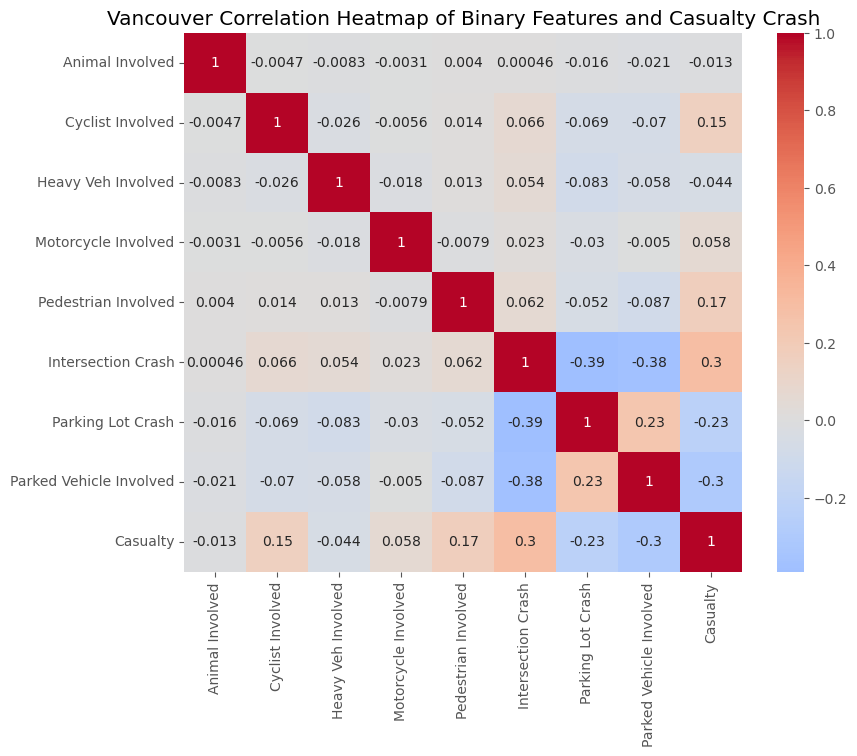

In [33]:
plt.figure(figsize=(9, 7))
plt.title("Vancouver Correlation Heatmap of Binary Features and Casualty Crash")

sns.heatmap(binary_df.corr(), annot=True, cmap="coolwarm", center=0)

### Vancouver Intersection data QA

In [34]:
print(vancouver_df["Intersection Crash"].value_counts())

Intersection Crash
Yes    131774
No      93374
Name: count, dtype: int64


In [35]:
print(vancouver_df["Cross Street Full Name"].isna().mean())

0.3833211931707144


In [36]:
print(vancouver_df["Street Full Name (ifnull)"].isna().mean())

5.3298274912502e-05


<Axes: ylabel='Intersection'>

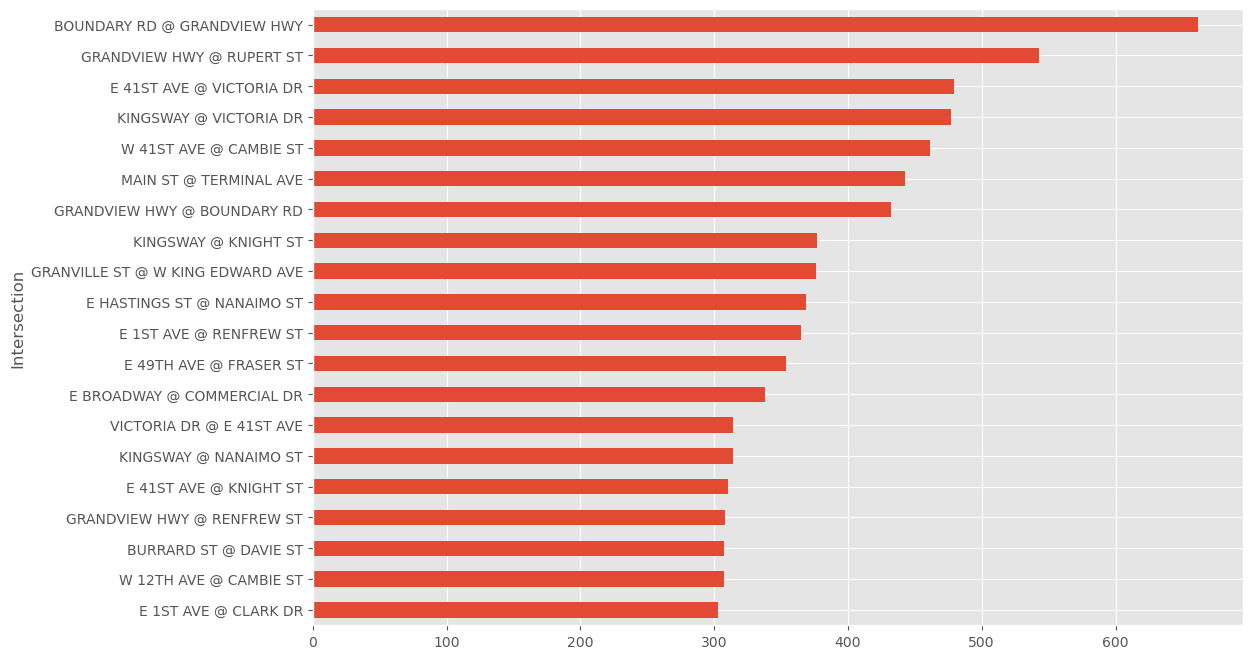

In [37]:
# crashes by intersection in vancouver

intersection_df = vancouver_df[
    (vancouver_df["Intersection Crash"] == "Yes")
    & (vancouver_df["Cross Street Full Name"].notna())
].copy()

intersection_df["Intersection"] = (
    intersection_df["Street Full Name (ifnull)"]
    + " @ "
    + intersection_df["Cross Street Full Name"]
)

intersection_df["Intersection"].value_counts().head(20).sort_values().plot.barh(
    figsize=(12, 8)
)

<Axes: title={'center': 'Top 20 Vancouver Intersections by Casualty Crash Count'}, ylabel='Intersection'>

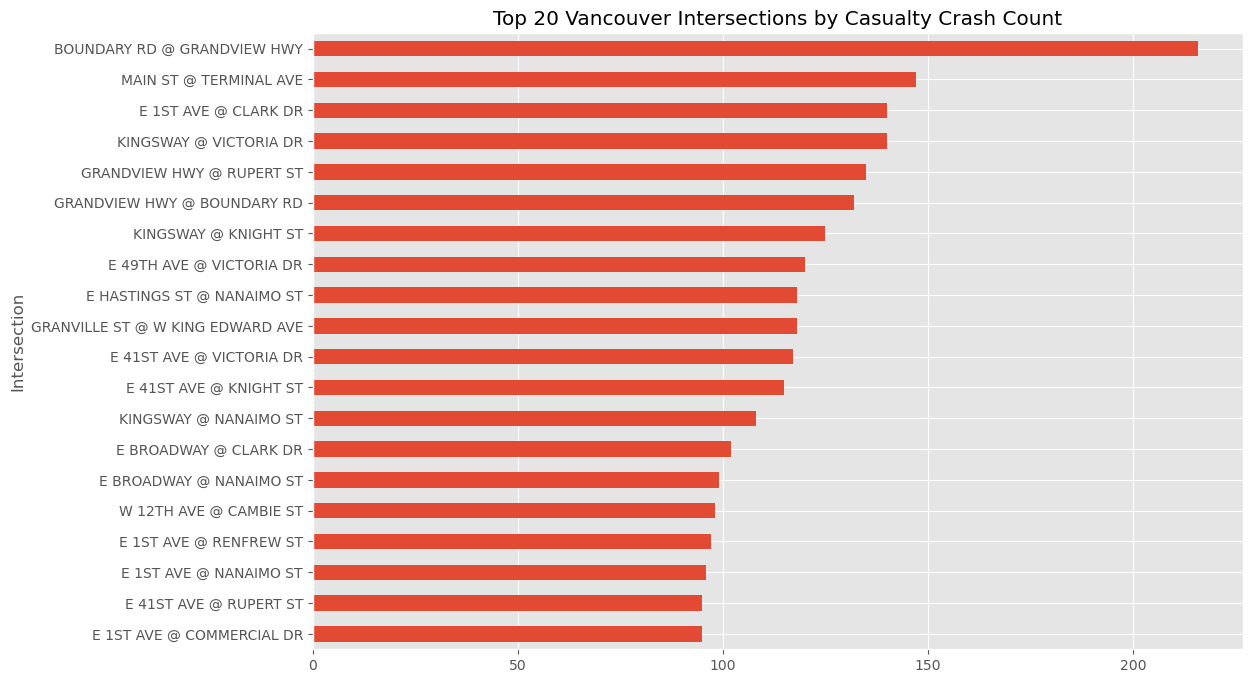

In [38]:
# Top intersections by casualty crashes in Vancouver

casualty = vancouver_df[
    (vancouver_df["Crash Severity"] == "CASUALTY CRASH")
    & (vancouver_df["Intersection Crash"] == "Yes")
    & (vancouver_df["Cross Street Full Name"].notna())
].copy()

casualty["Intersection"] = (
    casualty["Street Full Name (ifnull)"] + " @ " + casualty["Cross Street Full Name"]
)

casualty["Intersection"].value_counts().head(20).sort_values().plot.barh(
    figsize=(12, 8), title="Top 20 Vancouver Intersections by Casualty Crash Count"
)

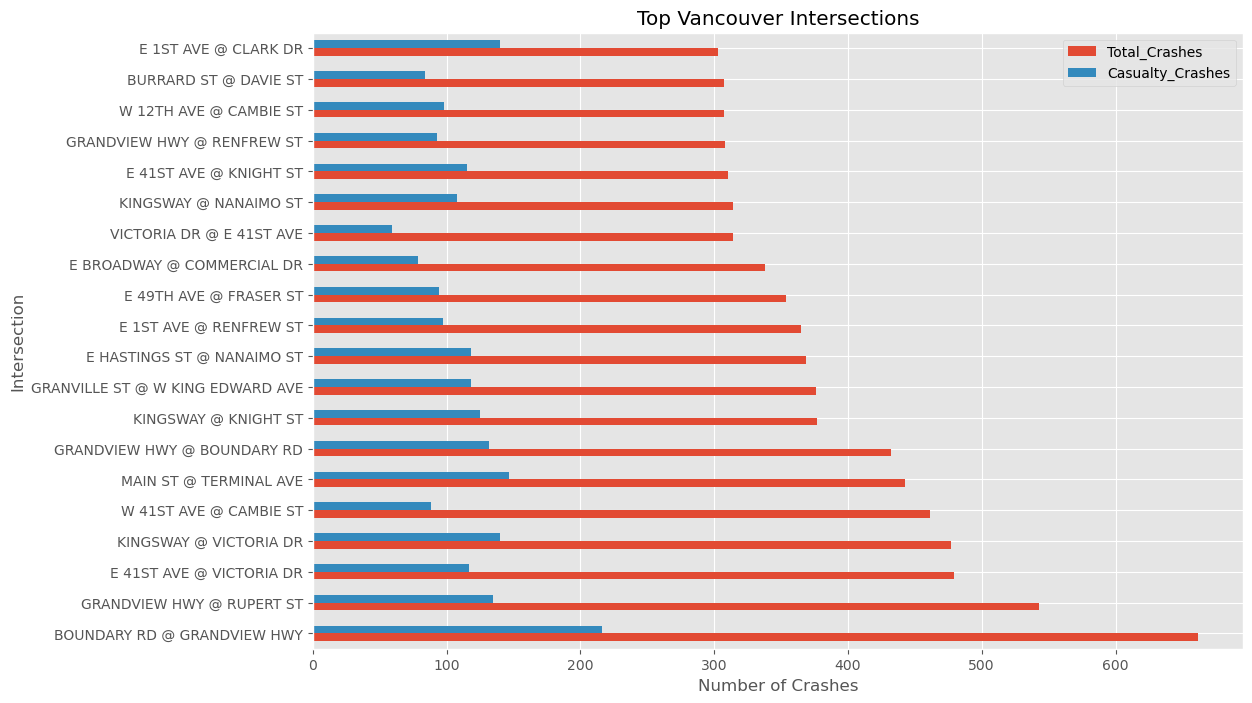

In [39]:
intersection_df = vancouver_df[
    (vancouver_df["Intersection Crash"] == "Yes")
    & (vancouver_df["Cross Street Full Name"].notna())
].copy()

intersection_df["Intersection"] = (
    intersection_df["Street Full Name (ifnull)"]
    + " @ "
    + intersection_df["Cross Street Full Name"]
)

summary = intersection_df.groupby("Intersection").agg(
    Total_Crashes=("Crash Severity", "size"),
    Casualty_Crashes=("Crash Severity", lambda x: (x == "CASUALTY CRASH").sum()),
)

top20 = summary.sort_values("Total_Crashes", ascending=False).head(20)

top20.plot.barh(y=["Total_Crashes", "Casualty_Crashes"], figsize=(12, 8))

plt.title("Top Vancouver Intersections")
plt.xlabel("Number of Crashes")
plt.show()

Text(0.5, 1.0, 'Total vs Casualty Crashes by Vancouver Intersection')

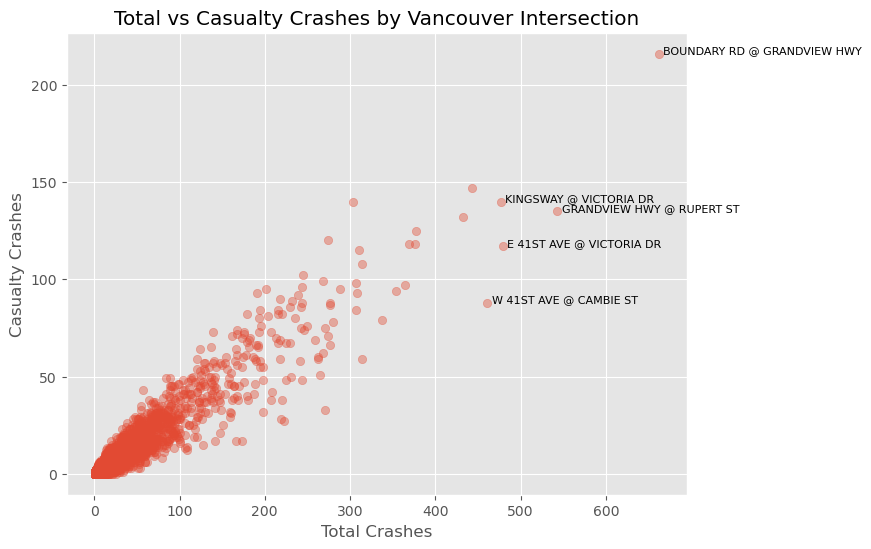

In [40]:
top = summary.nlargest(5, "Total_Crashes")

plt.figure(figsize=(8, 6))
plt.scatter(summary["Total_Crashes"], summary["Casualty_Crashes"], alpha=0.4)

for idx, row in top.iterrows():
    plt.text(row["Total_Crashes"] + 5, row["Casualty_Crashes"], idx, fontsize=8)

plt.xlabel("Total Crashes")
plt.ylabel("Casualty Crashes")
plt.title("Total vs Casualty Crashes by Vancouver Intersection")

In [41]:
corr = summary["Total_Crashes"].corr(summary["Casualty_Crashes"])
print(f"Pearson correlation: {corr:.3f}")

Pearson correlation: 0.952


- There is a strong positive relationship between the total number of crashes at an intersection and the number of casualty crashes. Intersections with higher crash volumes also tend to experience more injury crashes.
- Most intersections cluster near the origin, indicating that the majority of Vancouver intersections experience relatively few crashes over the five-year period.
- A small number of intersections stand out as high-volume outliers, with Boundary Rd @ Grandview Hwy being the most prominent.
- There are a few intersections with similar total crash counts but noticeably different casualty counts (for example, W 41st Ave @ Cambie St versus Kingsway @ Victoria Dr), suggesting that crash volume alone may not fully explain casualty risk.

In [42]:
vancouver_df[["Latitude", "Longitude", "Municipality With Boundary"]].isna().mean()

Latitude                      0.102031
Longitude                     0.102031
Municipality With Boundary    0.102031
dtype: float64

In [43]:
(vancouver_df["Latitude"].isna() == vancouver_df["Longitude"].isna()).mean()

np.float64(1.0)

In [44]:
intersection_df[["Latitude", "Longitude"]].isna().mean()

Latitude     0.0
Longitude    0.0
dtype: float64

Within the Vancouver subset, approximately 10.2% of records are missing latitude and longitude coordinates. These fields are always missing together, indicating a common source of missingness rather than independent data quality issues. Since the majority (89.8%) of crash records retain valid coordinates, there is sufficient spatial information for exploratory geographic analyses. Coordinate availability will be considered when selecting records for any map-based visualizations.

# Summary of Findings

The exploratory data analysis (EDA) phase has been completed on the ICBC crash dataset using only records from the City of Vancouver, consistent with the project scope defined by the client. The dataset was inspected for completeness, cleaned where appropriate, and filtered to Vancouver crashes before conducting exploratory analyses.

The EDA examined temporal trends, crash severity, crash characteristics, and spatial patterns to better understand where and when casualty crashes occur. Visualizations were created to explore crash frequency by year, month, day of week, and time of day, as well as relationships between crash severity and characteristics such as pedestrian involvement, cyclist involvement, motorcycle involvement, heavy vehicle involvement, and intersection crashes.

### Key Findings

- The Vancouver subset contains approximately **225,000** crash records between **2018 - 2022**, with roughly **20%** classified as casualty crashes and **80%** as property-damage-only crashes. This represents a moderately imbalanced classification problem.

- Crash frequency varies over time. Most crashes occur during weekday daytime and afternoon hours (approximately **12:00–18:00**), with fewer crashes overnight. A noticeable decline in crash counts is observed during **2020**, followed by recovery in 2021–2022.

- Rear-end, side-impact, and single-vehicle collisions are the most common crash configurations within Vancouver.

- Several binary crash characteristics show meaningful relationships with casualty crashes. Crashes involving pedestrians, cyclists, motorcycles, and intersections are substantially more likely to result in injuries than the overall average, while parking lot crashes are rarely casualty crashes.

- A relatively small number of intersections account for a disproportionately large number of crashes, suggesting that historical intersection crash patterns may be valuable predictors of future casualty risk.

- Missing data is generally limited. The primary missing field is **Cross Street Full Name**, which is expected because many crashes occur away from intersections. This will be considered during feature engineering.

### Implications for Modeling

The exploratory analysis suggests that historical crash records contain meaningful information for predicting future casualty crash risk at Vancouver intersections. Variables describing crash history, temporal patterns, crash configuration, and vulnerable road user involvement exhibit meaningful associations with casualty crashes and will be explored as candidate predictive features during model development.

The client's objective is interpreted as forecasting future casualty crash risk to prioritize engineering interventions. Because the dataset ends in 2022, no 2023 observations are available for evaluating a true forward prediction. Therefore, this project uses historical crash information available through 2021 to predict casualty crashes in 2022. This creates a realistic historical forecasting scenario that allows model performance to be quantitatively evaluated. Once validated, the same modeling approach could be retrained using all available data and applied operationally to forecast risk in subsequent years.

The next phase of the project will aggregate individual crash records into intersection-year summaries and engineer historical features for each intersection.